Extract ho gaya! Ab files: ['.config', 'archive.zip', '.ipynb_checkpoints', 'Mall_Customers.csv', 'drive', 'sample_data']

Dataset Preview:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Customers in Each Segment:
Segment_Name
Careful - High Income Low Spending          81
Standard - Medium Income Medium Spending    39
Sensitive - Low Income High Spending        35
Need-Focus - Low Income Low Spending        23
VIP - Target - High Income High Spending    22
Name: count, dtype: int64


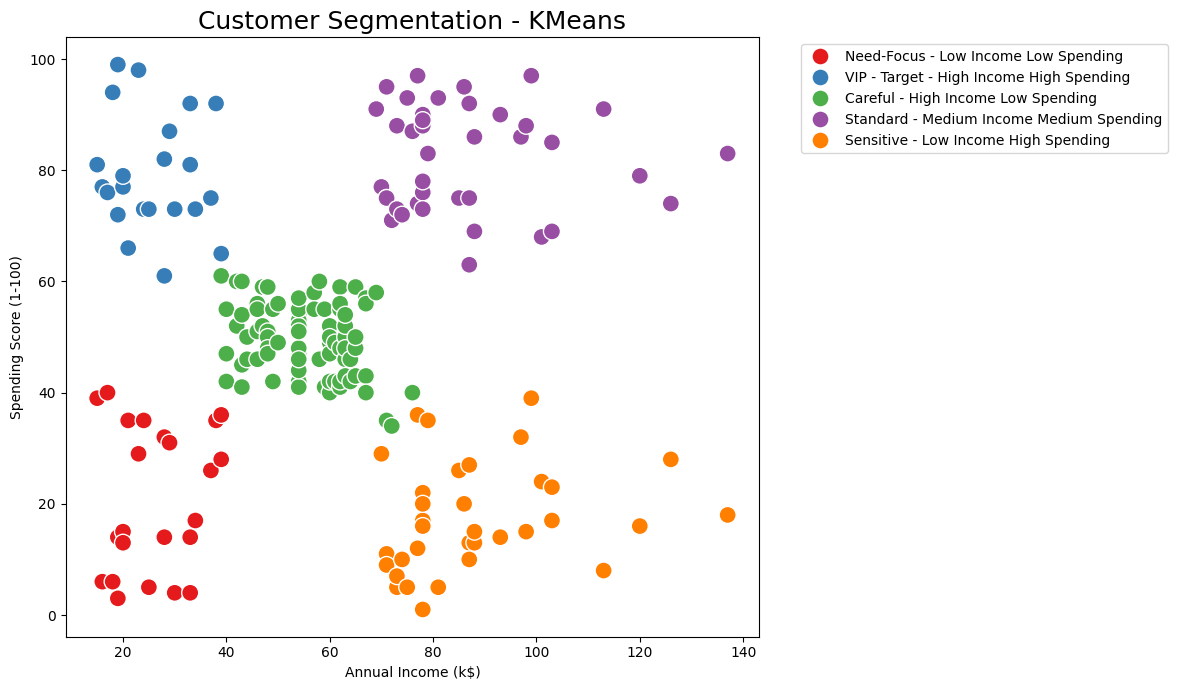


✅ DONE! Left Files me 2 nayi file aa gayi: segmentation_chart.png aur Segmented_Customers.csv


In [23]:
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# STEP 1: ZIP FILE EXTRACT KARO
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall()
print("Extract ho gaya! Ab files:", os.listdir())

# STEP 2: DATA LOAD - Dhyan: naam 'Mall_Customers.csv' hai
df = pd.read_csv('Mall_Customers.csv')
print("\nDataset Preview:")
print(df.head())

# STEP 3: FEATURES
X = df[['Annual Income (k$)','Spending Score (1-100)']]

# STEP 4: NORMALIZE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 5: K-MEANS
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(X_scaled)

# STEP 6: SEGMENT NAAM
segment_names = {
    0: "Careful - High Income Low Spending",
    1: "Standard - Medium Income Medium Spending",
    2: "VIP - Target - High Income High Spending",
    3: "Sensitive - Low Income High Spending",
    4: "Need-Focus - Low Income Low Spending"
}
df['Segment_Name'] = df['Segment'].map(segment_names)

print("\nCustomers in Each Segment:")
print(df['Segment_Name'].value_counts())

# STEP 7: GRAPH
plt.figure(figsize=(12,7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Segment_Name', data=df, palette='Set1', s=150)
plt.title('Customer Segmentation - KMeans', fontsize=18)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.savefig('segmentation_chart.png', dpi=300)
plt.show()

# STEP 8: SAVE
df.to_csv('Segmented_Customers.csv', index=False)
print("\n✅ DONE! Left Files me 2 nayi file aa gayi: segmentation_chart.png aur Segmented_Customers.csv")